# Possible paper:

Question: When numerically optimising fermion encodings, 
1. what are the possible metrics? 
    1. Pauli-weight of majorana strings in encoding.
    2. Pauli-weight of majorana strings in encoded fermionic operators.
    3. Pauli-weight of majorana strings in encoded Hamiltonian terms (without coefficients).

    --- Coefficients Needed so enumeration scheme relevant ---

    4. Pauli-weight of majorana strings in non-zero Hamiltonian terms.
    5. Coefficient-scaled Pauli-weight of majorana strings in encoded Hamiltonian terms.

    --- Ansatz / Algorithm Needed ---

    6. Circuit Depth
    7. Two qubit gates

    --- Native gates and topology needed ---

    8. Transpiled Cicruit Depth
    9. Transpiled Two-qubit gates
    8. Energy accuracy

2. How well do these relate to eachother?
3. How well do these predict the quality of the final circuit?

- [ ]

In [1]:
import pickle
from ferrmion.encode import TernaryTree, MaxNTO
from ferrmion.optimize.huffman import huffman_ternary_tree
from pathlib import Path

def water_integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
        ones = pickle.load(file)

    with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
        twos = pickle.load(file)
    return (ones, twos)

tree = TernaryTree(14)

## 1.1 $P_{HI}$ Hamiltonian Independent

- Take only the mean of the majorana-string lengths

In [2]:
from ferrmion import FermionQubitEncoding
import numpy as np
def hamiltonian_indpendent_weight(encoding: FermionQubitEncoding):
    _, symplectics = encoding._build_symplectic_matrix()
    x_block, z_block = np.hsplit(symplectics, 2)
    operator_weights = np.sum(np.bitwise_or(x_block, z_block),axis=1)
    return operator_weights

In [3]:
ham_indep = {"jw":None,"pe": None,"bk": None,"jkmn": None}
ham_indep["jw"]=hamiltonian_indpendent_weight(tree.JordanWigner())
ham_indep["pe"]=hamiltonian_indpendent_weight(tree.ParityEncoding())
ham_indep["bk"]=hamiltonian_indpendent_weight(tree.BravyiKitaev())
ham_indep["jkmn"]=hamiltonian_indpendent_weight(tree.JKMN())
ham_indep["maxnto"]=hamiltonian_indpendent_weight(MaxNTO(14))

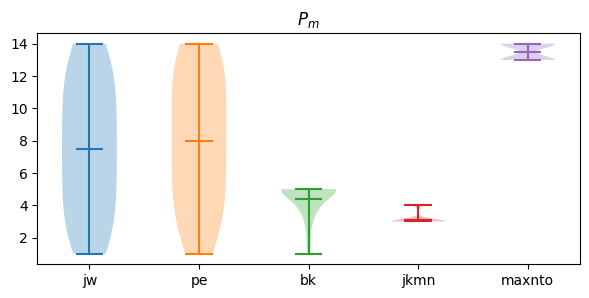

In [4]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def operator_violin_plot(operators:dict, title:str):
    #create histogram
    n_bins = 30
    alpha = 0.7

    fig, axs = plt.subplots(figsize=(7,3))
    pos = 0
    for dist in operators.values():
        axs.violinplot(dist, [pos], showmeans=True)
        pos+=1

    axs.set_xticks([*range(len(operators))], labels=operators.keys())
    plt.title(title)
    plt.show()

operator_violin_plot(ham_indep, title="$P_{m}$")

## 1.2 Pauli-weight of strings in encoded fermionic operators.

### Edge Operators

In [5]:
from qiskit.circuit.library import PauliGate
from qiskit.quantum_info import SparsePauliOp
from itertools import product
from ferrmion.encode import JW, BK, ParityEncoding, JKMN, MaxNTO

encoding_funcs = {"jw":JW, "bk":BK, "pe":ParityEncoding, "jkmn":JKMN, "maxnto":MaxNTO}
edge_ops = {}
for name, func in encoding_funcs.items():
    print(name)
    encoding = func(14)
    edge_ops[name] = set()
    mode_range = range(encoding.n_modes)
    for i,j in product(mode_range, mode_range):
        paulis = SparsePauliOp.from_sparse_list(encoding.edge_operator((i,j)), num_qubits=encoding.n_modes).simplify().paulis
        edge_ops[name].update([str(p) for p in paulis])

for name, ops in edge_ops.items():
    edge_ops[name] = [len(op)-op.count("I") for op in ops]

jw
bk
pe
jkmn
maxnto


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_64307/3498452244.py:1: SyntaxWarning: invalid escape sequence '\d'
  operator_violin_plot(edge_ops, title="$a_i^{\dagger}a_j$")


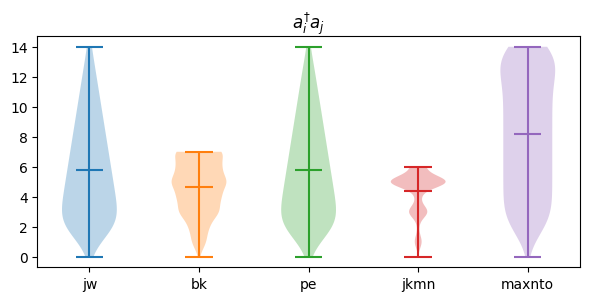

In [6]:
operator_violin_plot(edge_ops, title="$a_i^{\dagger}a_j$")

## Number Operators

In [7]:
from qiskit.circuit.library import PauliGate
from qiskit.quantum_info import SparsePauliOp
from itertools import product
from ferrmion.encode import JW, BK, ParityEncoding, JKMN, MaxNTO

encoding_funcs = {"jw":JW, "bk":BK, "pe":ParityEncoding, "jkmn":JKMN, "maxnto":MaxNTO}
number_ops = {}
for name, func in encoding_funcs.items():
    print(name)
    encoding = func(14)
    number_ops[name] = set()
    mode_range = range(encoding.n_modes)
    for i in mode_range:
        paulis = SparsePauliOp.from_sparse_list(encoding.number_operator(i), num_qubits=encoding.n_modes).simplify().paulis
        number_ops[name].update([str(p) for p in paulis])

for name, ops in number_ops.items():
    number_ops[name] = [len(op)-op.count("I") for op in ops]

jw
bk
pe
jkmn
maxnto


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_64307/3181693846.py:1: SyntaxWarning: invalid escape sequence '\d'
  operator_violin_plot(number_ops, title="$a_i^{\dagger}a_i$")


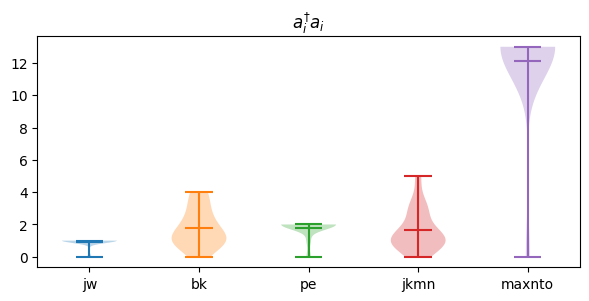

In [8]:
operator_violin_plot(number_ops, title="$a_i^{\dagger}a_i$")

## Double Excitation Operators

In [10]:
from ferrmion.encode.base import double_fermionic_operator
print("MaxNTO")
encoding = MaxNTO(4)
for i in range(encoding.n_modes):
    for j in range(i, encoding.n_modes):
        paulis = SparsePauliOp.from_sparse_list(double_fermionic_operator(encoding, (i,j), "++"), num_qubits=encoding.n_modes).simplify().paulis
        print(i,j, paulis)
print()
print("JW")
encoding = JW(4)
for i in range(encoding.n_modes):
    for j in range(i, encoding.n_modes):
        paulis = SparsePauliOp.from_sparse_list(double_fermionic_operator(encoding, (i,j), "++"), num_qubits=encoding.n_modes).simplify().paulis
        print(i,j, paulis)

MaxNTO
0 0 ['IIII']
0 1 ['ZZXY', 'IIXX', 'IIYY', 'ZZYX']
0 2 ['IYZX', 'ZYIY', 'ZXIX', 'IXZY']
0 3 ['XIIY', 'XZZX', 'YZZY', 'YIIX']
1 1 ['IIII']
1 2 ['ZXYZ', 'IXXI', 'IYYI', 'ZYXZ']
1 3 ['YZXI', 'YIYZ', 'XIXZ', 'XZYI']
2 2 ['IIII']
2 3 ['XYZZ', 'XXII', 'YYII', 'YXZZ']
3 3 ['IIII']

JW
0 0 ['IIII']
0 1 ['IIXY', 'IIYY', 'IIXX', 'IIYX']
0 2 ['IXZY', 'IYZY', 'IXZX', 'IYZX']
0 3 ['XZZY', 'YZZY', 'XZZX', 'YZZX']
1 1 ['IIII']
1 2 ['IXYI', 'IYYI', 'IXXI', 'IYXI']
1 3 ['XZYI', 'YZYI', 'XZXI', 'YZXI']
2 2 ['IIII']
2 3 ['XYII', 'YYII', 'XXII', 'YXII']
3 3 ['IIII']


<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_64307/859234630.py:22: SyntaxWarning: invalid escape sequence '\d'
  operator_violin_plot(double_creation_ops, "$P_{a_i^{\dagger}a_j^{\dagger}}$")


jw
bk
pe
jkmn
maxnto


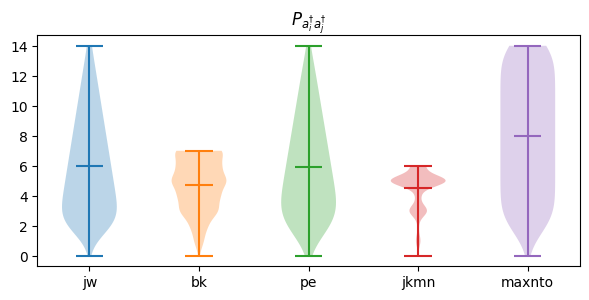

In [11]:
from qiskit.circuit.library import PauliGate
from qiskit.quantum_info import SparsePauliOp
from itertools import product
from ferrmion.encode import JW, BK, ParityEncoding, JKMN, MaxNTO
from ferrmion.encode.base import double_fermionic_operator

encoding_funcs = {"jw":JW, "bk":BK, "pe":ParityEncoding, "jkmn":JKMN, "maxnto":MaxNTO}
double_creation_ops = {}
for name, func in encoding_funcs.items():
    print(name)
    encoding = func(14)
    double_creation_ops[name] = set()
    mode_range = range(encoding.n_modes)
    for i in mode_range:
        for j in range(i, encoding.n_modes):
            paulis = SparsePauliOp.from_sparse_list(double_fermionic_operator(encoding, (i,j), "++"), num_qubits=encoding.n_modes).simplify().paulis
            double_creation_ops[name].update([str(p) for p in paulis])

for name, ops in double_creation_ops.items():
    double_creation_ops[name] = [len(op)-op.count("I") for op in ops]

operator_violin_plot(double_creation_ops, "$P_{a_i^{\dagger}a_j^{\dagger}}$")

### Exchange Operators

In [38]:
from qiskit.circuit.library import PauliGate
from qiskit.quantum_info import SparsePauliOp
from itertools import product
from ferrmion.encode import JW, BK, ParityEncoding, JKMN, MaxNTO
import itertools

encoding_funcs = {"jw":JW, "bk":BK, "pe":ParityEncoding, "jkmn":JKMN, "maxnto":MaxNTO}
exchange_ops = {}
for name, func in encoding_funcs.items():
    print(name)
    encoding = func(14)
    exchange_ops[name] = set()
    mode_range = range(encoding.n_modes)
    for i,j,k,l in itertools.product(mode_range, repeat=4):
        lpaulis = SparsePauliOp.from_sparse_list(encoding.edge_operator((i,j)), num_qubits=encoding.n_modes).simplify()
        rpaulis = SparsePauliOp.from_sparse_list(encoding.edge_operator((k,l)), num_qubits=encoding.n_modes)
        paulis = lpaulis.compose(rpaulis).simplify().paulis
        exchange_ops[name].update([str(p) for p in paulis])

for name, ops in exchange_ops.items():
    exchange_ops[name] = [len(op)-op.count("I") for op in ops]

jw


SystemError: <class 'itertools.product'> returned a result with an exception set

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_64307/2921170506.py:1: SyntaxWarning: invalid escape sequence '\d'
  operator_violin_plot(exchange_ops, "$P_{a_i^{\dagger}a_ja_k^{\dagger}a_l}$")


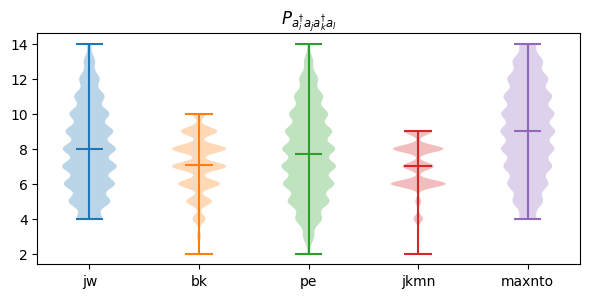

In [16]:
operator_violin_plot(exchange_ops, "$P_{a_i^{\dagger}a_ja_k^{\dagger}a_l}$")

## Double Number Operator

In [39]:
print("MaxNTO")
encoding = MaxNTO(4)
for i in range(encoding.n_modes):
    lpaulis = SparsePauliOp.from_sparse_list(encoding.number_operator(i), num_qubits=encoding.n_modes).simplify()
    for k in range(encoding.n_modes):
        rpaulis = SparsePauliOp.from_sparse_list(encoding.number_operator(k), num_qubits=encoding.n_modes)
        paulis = lpaulis.compose(rpaulis).simplify().paulis
        print(i,k, paulis)
print()
print("JW")
encoding = JW(4)
for i in range(encoding.n_modes):
    lpaulis = SparsePauliOp.from_sparse_list(encoding.number_operator(i), num_qubits=encoding.n_modes).simplify()
    for k in range(encoding.n_modes):
        rpaulis = SparsePauliOp.from_sparse_list(encoding.number_operator(k), num_qubits=encoding.n_modes)
        paulis = lpaulis.compose(rpaulis).simplify().paulis
        print(i,k, paulis)
print()

MaxNTO
0 0 ['IIII', 'ZZZI']
0 1 ['IIII', 'ZZIZ', 'ZZZI', 'IIZZ']
0 2 ['IIII', 'ZIZZ', 'ZZZI', 'IZIZ']
0 3 ['IIII', 'IZZZ', 'ZZZI', 'ZIIZ']
1 0 ['IIII', 'ZZZI', 'ZZIZ', 'IIZZ']
1 1 ['IIII', 'ZZIZ']
1 2 ['IIII', 'ZIZZ', 'ZZIZ', 'IZZI']
1 3 ['IIII', 'IZZZ', 'ZZIZ', 'ZIZI']
2 0 ['IIII', 'ZZZI', 'ZIZZ', 'IZIZ']
2 1 ['IIII', 'ZZIZ', 'ZIZZ', 'IZZI']
2 2 ['IIII', 'ZIZZ']
2 3 ['IIII', 'IZZZ', 'ZIZZ', 'ZZII']
3 0 ['IIII', 'ZZZI', 'IZZZ', 'ZIIZ']
3 1 ['IIII', 'ZZIZ', 'IZZZ', 'ZIZI']
3 2 ['IIII', 'ZIZZ', 'IZZZ', 'ZZII']
3 3 ['IIII', 'IZZZ']

JW
0 0 ['IIII', 'IIIZ']
0 1 ['IIII', 'IIZI', 'IIIZ', 'IIZZ']
0 2 ['IIII', 'IZII', 'IIIZ', 'IZIZ']
0 3 ['IIII', 'ZIII', 'IIIZ', 'ZIIZ']
1 0 ['IIII', 'IIIZ', 'IIZI', 'IIZZ']
1 1 ['IIII', 'IIZI']
1 2 ['IIII', 'IZII', 'IIZI', 'IZZI']
1 3 ['IIII', 'ZIII', 'IIZI', 'ZIZI']
2 0 ['IIII', 'IIIZ', 'IZII', 'IZIZ']
2 1 ['IIII', 'IIZI', 'IZII', 'IZZI']
2 2 ['IIII', 'IZII']
2 3 ['IIII', 'ZIII', 'IZII', 'ZZII']
3 0 ['IIII', 'IIIZ', 'ZIII', 'ZIIZ']
3 1 ['IIII', 'IIZI', 'ZIII',

In [40]:
from qiskit.circuit.library import PauliGate
from qiskit.quantum_info import SparsePauliOp
from itertools import product
from ferrmion.encode import JW, BK, ParityEncoding, JKMN, MaxNTO

encoding_funcs = {"jw":JW, "bk":BK, "pe":ParityEncoding, "jkmn":JKMN, "maxnto":MaxNTO}
doublenumber = {}
for name, func in encoding_funcs.items():
    print(name)
    encoding = func(14)
    doublenumber[name] = set()
    mode_range = range(encoding.n_modes)
    for i in mode_range:
        lpaulis = SparsePauliOp.from_sparse_list(encoding.number_operator(i), num_qubits=encoding.n_modes).simplify()
        for k in mode_range:
            rpaulis = SparsePauliOp.from_sparse_list(encoding.number_operator(k), num_qubits=encoding.n_modes)
            paulis = lpaulis.compose(rpaulis).simplify().paulis
            doublenumber[name].update([str(p) for p in paulis])

for name, ops in doublenumber.items():
    doublenumber[name] = [len(op)-op.count("I") for op in ops]

jw
bk
pe
jkmn
maxnto


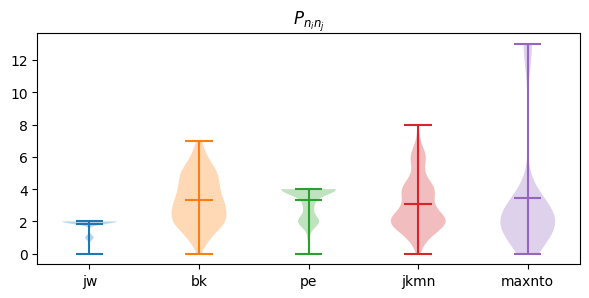

In [41]:
operator_violin_plot(doublenumber, "$P_{n_i n_j}$")

<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_64307/4173796378.py:16: SyntaxWarning: invalid escape sequence '\d'
  axs[0].title.set_text("$P_{a_i^{\dagger}a_j}$")
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_64307/4173796378.py:18: SyntaxWarning: invalid escape sequence '\d'
  axs[2].title.set_text("$P_{a_i^{\dagger}a_j^{\dagger}}$")
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_64307/4173796378.py:19: SyntaxWarning: invalid escape sequence '\d'
  axs[3].title.set_text("$P_{a_i^{\dagger}a_j a_k^{\dagger}a_l}$")
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_64307/4173796378.py:16: SyntaxWarning: invalid escape sequence '\d'
  axs[0].

UFuncTypeError: ufunc 'minimum' did not contain a loop with signature matching types (dtype('<U14'), dtype('<U14')) -> None

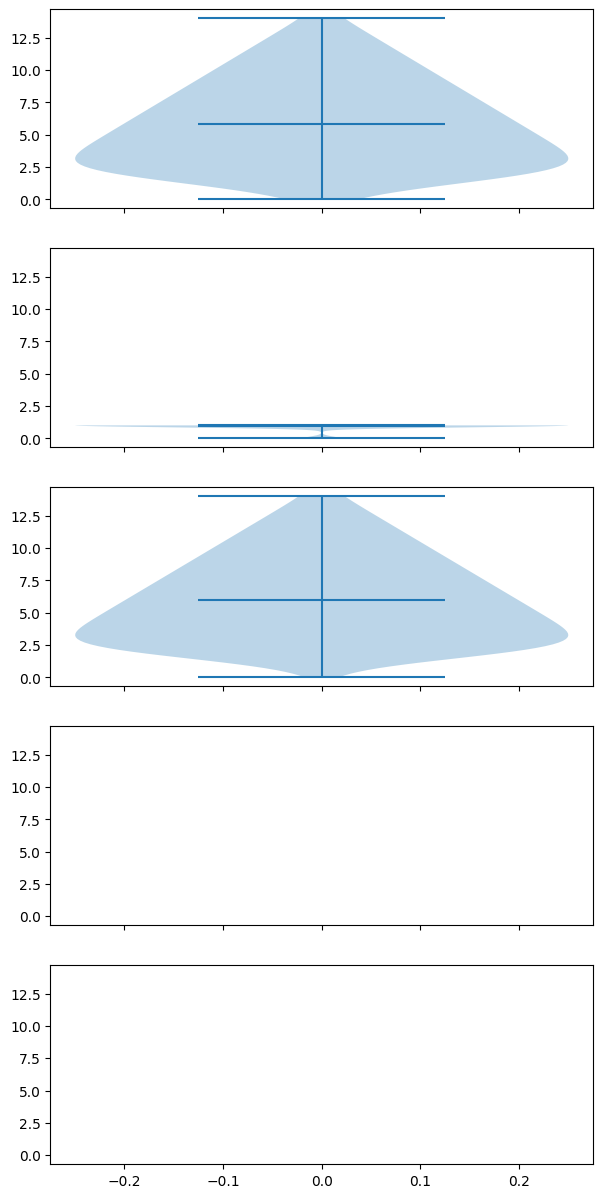

In [42]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
#create histogram
n_bins = 30
alpha = 0.7

fig, axs = plt.subplots(5,1, sharey=True, figsize=(7,15), sharex=True)
pos = 0
for k in edge_ops.keys():
    axs[0].violinplot(edge_ops[k], [pos], showmeans=True)
    axs[1].violinplot(number_ops[k], [pos], showmeans=True)
    axs[2].violinplot(double_creation_ops[k], [pos], showmeans=True)
    axs[3].violinplot(exchange_ops[k], [pos], showmeans=True)
    axs[4].violinplot(doublenumber[k], [pos], showmeans=True)
    pos+=1
axs[0].title.set_text("$P_{a_i^{\dagger}a_j}$")
axs[1].title.set_text("$P_{n_i}$")
axs[2].title.set_text("$P_{a_i^{\dagger}a_j^{\dagger}}$")
axs[3].title.set_text("$P_{a_i^{\dagger}a_j a_k^{\dagger}a_l}$")
axs[4].title.set_text("$P_{n_i n_j}$")
axs[0].set_xticks([*range(len(edge_ops))], labels=edge_ops.keys())
plt.show()

## 1.3 Pauli-weight of majorana strings in encoded Hamiltonian terms (without coefficients).

This is just the combination of the $a^{\dagger}a$ and $a^{\dagger}aa^{\dagger}a$ terms above

In [45]:
from ferrmion.optimize.enumeration import lambda_plus_mu
from ferrmion.hamiltonians import molecular_hamiltonian_template
from ferrmion.hamiltonians import fill_template
from ferrmion.optimize import huffman_ternary_tree, hamiltonian_adaptive_ternary_tree, bonsai_algorithm
from ferrmion.utils import fermionic_to_sparse_majorana
import functools
ones, twos = water_integrals()

templates = {"jw":None,"pe": None,"bk": None,"jkmn": None}

ipowers, symplectics = tree.JW()._build_symplectic_matrix()
templates["jw"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

ipowers, symplectics = tree.ParityEncoding()._build_symplectic_matrix()
templates["pe"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

ipowers, symplectics = tree.BK()._build_symplectic_matrix()
templates["bk"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

ipowers, symplectics = tree.JKMN()._build_symplectic_matrix()
templates["jkmn"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

ipowers, symplectics = MaxNTO(14)._build_symplectic_matrix()
templates["maxnto"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)


In [47]:
huffman_tree = huffman_ternary_tree(ones, twos)
ipowers, symplectics = huffman_tree._build_symplectic_matrix()
templates["huffman"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

hatt_tree = hamiltonian_adaptive_ternary_tree(fermionic_to_sparse_majorana([(ones, "+-"),(twos,"++--")]), 14)
ipowers, symplectics = hatt_tree._build_symplectic_matrix() 
templates["hatt"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

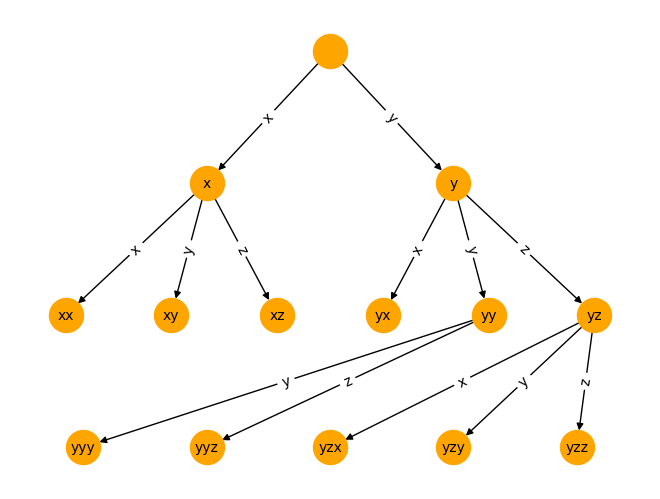

In [56]:
from ferrmion.visualise import draw_tt
draw_tt(huffman_tree)


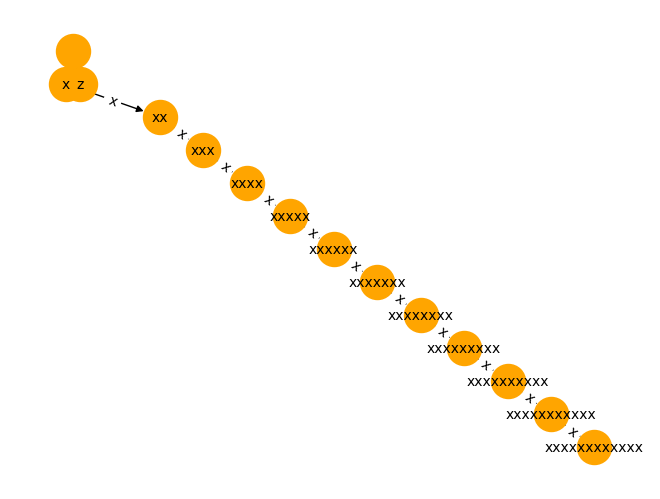

In [57]:
draw_tt(hatt_tree)

In [48]:
import numpy as np
def template_pauli_weight(template):
    return [len(k) - k.count("I") for k in template.keys()]

ham_dep = {k: template_pauli_weight(v) for k,v in templates.items()}

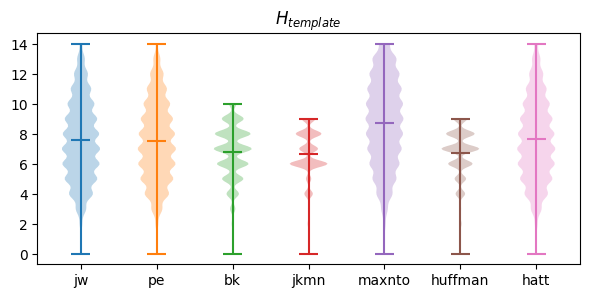

In [49]:
operator_violin_plot(ham_dep, title="$H_{template}$")

## 1.4 Pauli-weight of majorana strings in non-zero Hamiltonian terms.
`unscaled` as filled hamiltonian does not contain 0 value terms.

## 1.5 Coefficient-scaled Pauli-weight of majorana strings in encoded Hamiltonian terms.
`scaled`

In [50]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [51]:
def fill_template_find_norms(template, ones, twos, permutation):
    permutation = np.array(permutation, dtype=np.uint)
    ham = fill_template(template, 0, ones, 0.5*twos, permutation)
    
    return pauli_weights(ham)

In [52]:
limit = 100
sdmeans = {}
sdmeans_naive = {}
rng = np.random.RandomState(1017)
for encoding, template in templates.items():
    sdmeans[encoding] = {"unscaled":[], "scaled":[], "length":[]}
    sdmeans_naive[encoding] = {"unscaled":[], "scaled":[], "length":[]}
    
    result = fill_template_find_norms(template, ones, twos, np.array([*range(14)], dtype=np.uint))
    sdmeans_naive[encoding]["unscaled"] = np.mean(result[0])
    sdmeans_naive[encoding]["scaled"] = np.mean(result[1])
    sdmeans_naive[encoding]["length"] = result[2]

    for i in range(100):
        perm = rng.permutation(14)
        result = fill_template_find_norms(template, ones, twos, perm)
        sdmeans[encoding]["unscaled"].append(np.mean(result[0])) 
        sdmeans[encoding]["scaled"].append(np.mean(result[1]))
        sdmeans[encoding]["length"].append(result[2])
        if i >= limit:
            break
        else:
            i+=1
sdmeans

{'jw': {'unscaled': [np.float64(7.101289134438305),
   np.float64(6.751381215469613),
   np.float64(6.808471454880294),
   np.float64(7.110497237569061),
   np.float64(6.620626151012892),
   np.float64(6.931860036832412),
   np.float64(6.972375690607735),
   np.float64(6.5451197053407),
   np.float64(7.088397790055248),
   np.float64(7.147329650092081),
   np.float64(6.394106813996316),
   np.float64(6.933701657458563),
   np.float64(6.567219152854512),
   np.float64(6.900552486187845),
   np.float64(7.031307550644567),
   np.float64(7.186003683241252),
   np.float64(7.081031307550645),
   np.float64(6.863720073664825),
   np.float64(6.786372007366483),
   np.float64(6.565377532228361),
   np.float64(6.902394106813996),
   np.float64(7.025782688766114),
   np.float64(7.10865561694291),
   np.float64(6.863720073664825),
   np.float64(6.65561694290976),
   np.float64(6.650092081031308),
   np.float64(6.998158379373849),
   np.float64(6.723756906077348),
   np.float64(7.10865561694291),
 

! All encodings have the same number of terms in their encoded hamiltonian.

In [53]:
for encoding in sdmeans.keys():
    assert len(set(sdmeans[encoding]["length"]))==1

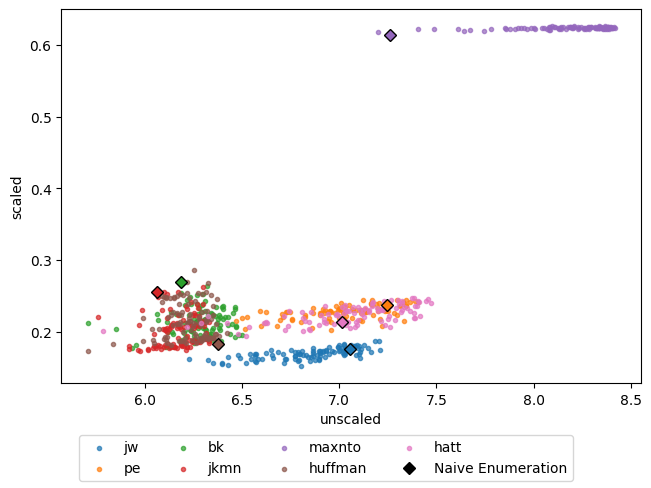

In [59]:
color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "maxnto":"tab:purple", "huffman":"tab:brown", "hatt":"tab:pink"}
fig, ax = plt.subplots(layout="constrained")
for encoding in sdmeans.keys():
    ax.scatter(sdmeans[encoding]["unscaled"], sdmeans[encoding]["scaled"], label=encoding, marker=".", color=color_set[encoding], alpha=0.7)
    ax.plot(sdmeans_naive[encoding]["unscaled"], sdmeans_naive[encoding]["scaled"], marker="D", color=color_set[encoding], mec="k")

#Imports
import matplotlib.lines as mlines

# where some data has already been plotted to ax
handles, labels = plt.gca().get_legend_handles_labels()

# manually define a new patch 
naive_legend = mlines.Line2D([], [], color='black', label='Naive Enumeration', marker="D", linestyle="")

# handles is a list, so append manual patch
handles.extend([naive_legend]) 
ax.set_xlabel("unscaled")
ax.set_ylabel("scaled")
fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)

## Simulated Annealing

Enumerations can also be optimised with simulated annealing. 

We just need to provide a temperature (using the number of modes tends to give good results) and an initial permutation.

In [ ]:
from ferrmion.core import anneal_enumerations

# temp = 14
annealed_best = {}
for temp in [14]:
    annealed_best[temp] = {}
    print("temp ", temp)
    for encoding in sdmeans.keys():
        print("encoding ", encoding)
        annealed_best[temp][encoding] = anneal_enumerations(templates[encoding], ones, 0.5*twos, temp, np.array([*range(14)],dtype=np.uint))

temp  14
encoding  jw
encoding  pe
encoding  bk
encoding  jkmn
encoding  knto
encoding  huffman


In [ ]:
annealed_best

{14: {'jw': (0.1334283199481575,
   array([ 0,  2,  6,  9, 10, 12,  4,  8, 11,  3,  5, 13,  7,  1],
         dtype=uint64)),
  'pe': (0.18476423566539962,
   array([ 6,  9,  2,  0, 10, 12,  4,  8,  7,  3,  5, 11, 13,  1],
         dtype=uint64)),
  'bk': (0.17405879755884962,
   array([10,  7,  3,  6,  4, 13,  9,  0, 12,  1, 11,  5,  8,  2],
         dtype=uint64)),
  'jkmn': (0.16841027365772437,
   array([10,  6,  4, 11, 13,  1, 12,  9,  2,  0,  8,  3,  7,  5],
         dtype=uint64)),
  'knto': (1.0450488526675592,
   array([ 7,  5, 13,  1,  0,  2, 10,  4, 12,  6,  8, 11,  3,  9],
         dtype=uint64)),
  'huffman': (0.17583325270296313,
   array([ 5,  8, 11,  3,  1,  9,  0,  6,  7, 13, 12, 10,  4,  2],
         dtype=uint64))}}

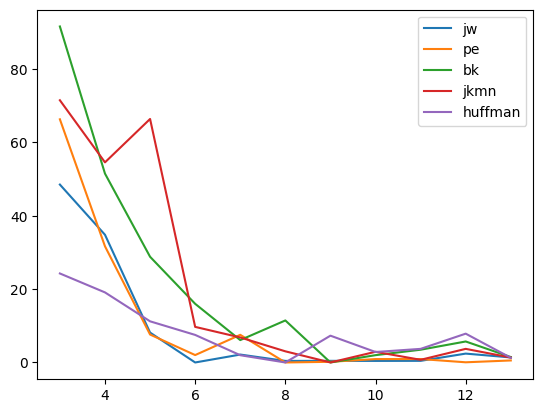

In [ ]:
for encoding in sdmeans.keys():
    if encoding == "maxnto":
        continue
    keys = [k for k in annealed_best.keys()][:13]
    values = [v[encoding][0] for v in annealed_best.values()][:13]
    val_diff = np.abs(np.array(values)-min(values))
    plt.plot(keys[2:], val_diff[2:], label=encoding)
plt.legend()

{'jw': (134.6496165114455,
  array([ 1,  7,  3, 11,  2, 10,  6,  0,  9,  8,  4, 12,  5, 13],
        dtype=uint64)),
 'pe': (190.43188988231594,
  array([ 8,  9,  5, 13,  6, 10,  2,  0, 12,  4,  3, 11,  7,  1],
        dtype=uint64)),
 'bk': (177.79555877417712,
  array([10,  9, 11,  2,  7,  4,  5,  6,  1,  3, 12,  8, 13,  0],
        dtype=uint64)),
 'jkmn': (170.7266398184265,
  array([11,  4,  7, 10, 13, 12,  9,  8,  1,  3,  6,  2,  0,  5],
        dtype=uint64)),
 'knto': (660.314566916443,
  array([ 3,  0,  1, 10,  7,  6,  8,  9,  4,  5, 12, 13,  2, 11],
        dtype=uint64)),
 'huffman': (183.26110112876424,
  array([ 7,  4,  8, 11,  3,  1, 10,  6,  0, 13,  2,  9, 12,  5],
        dtype=uint64))}

In [ ]:
sdmeans_annealed = {}
for temp, vals in annealed_best.items():
    sdmeans_annealed[temp] = {}
    this_dict = sdmeans_annealed[temp]
    for encoding, best in vals.items():
        this_dict[encoding] = {"unscaled":[], "scaled":[], "length":[]}
        result = fill_template_find_norms(templates[encoding], ones, twos, best[1])
        this_dict[encoding]["unscaled"].append(np.mean(result[0])) 
        this_dict[encoding]["scaled"].append(np.mean(result[1]))
        this_dict[encoding]["length"].append(result[2])

In [ ]:
sdmeans_annealed

{14: {'jw': {'unscaled': [np.float64(5.504604051565377)],
   'scaled': [np.float64(0.13342831994815732)],
   'length': [1086]},
  'pe': {'unscaled': [np.float64(5.641804788213628)],
   'scaled': [np.float64(0.18476423566539985)],
   'length': [1086]},
  'bk': {'unscaled': [np.float64(5.775322283609577)],
   'scaled': [np.float64(0.17405879755884973)],
   'length': [1086]},
  'jkmn': {'unscaled': [np.float64(5.988029465930018)],
   'scaled': [np.float64(0.16841027365772426)],
   'length': [1086]},
  'knto': {'unscaled': [np.float64(8.386740331491712)],
   'scaled': [np.float64(1.0450488526675588)],
   'length': [1086]},
  'huffman': {'unscaled': [np.float64(5.855432780847146)],
   'scaled': [np.float64(0.1758332527029629)],
   'length': [1086]}}}

<>:21: SyntaxWarning: invalid escape sequence '\ '
<>:21: SyntaxWarning: invalid escape sequence '\ '
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_79115/4066079690.py:21: SyntaxWarning: invalid escape sequence '\ '
  plt.title("$P_{SD}: H_{2}O\ STO-3G$")


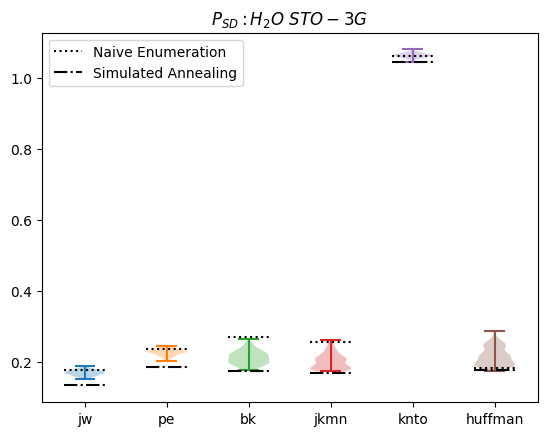

In [ ]:
fig, axs = plt.subplots()
pos = 0
for encoding, dist in sdmeans.items():
    n_terms = sdmeans_naive[encoding]["length"]
    # if encoding == "maxnto":
    #     continue
    dist = dist["scaled"]
    axs.violinplot(dist, [pos])
    pos+=1
axs.set_xticks([*range(len(sdmeans))], labels=[*sdmeans.keys()])
for pos, encoding in enumerate(sdmeans.keys()):
    # if encoding == "maxnto":
    #     continue
    axs.hlines(sdmeans_naive[encoding]["scaled"],  pos-0.25, pos+0.25,  linestyles=":", color="black")
    axs.hlines(sdmeans_annealed[14][encoding]["scaled"],  pos-0.25, pos+0.25,  linestyles="-.", color="black")

naive_line = mlines.Line2D([], [], color='black', linestyle=":", label="Naive Enumeration")
anneal_line = mlines.Line2D([], [], color='black', linestyle="-.", label="Simulated Annealing")
axs.legend(handles=[naive_line, anneal_line])

plt.title("$P_{SD}: H_{2}O\ STO-3G$")
plt.show()

In [ ]:
from ferrmion.core import template_weight_distribution
distributions = {k: template_weight_distribution(templates[k], 0., ones, 0.5*twos, 200) for k in templates.keys()}

<>:22: SyntaxWarning: invalid escape sequence '\ '
<>:22: SyntaxWarning: invalid escape sequence '\ '
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_66308/1222619953.py:22: SyntaxWarning: invalid escape sequence '\ '
  plt.title("$P_{SD}: H_{2}O\ STO-3G$")


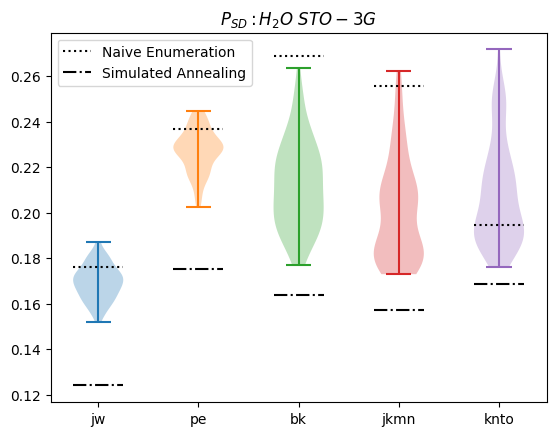

In [ ]:
fig, axs = plt.subplots()
pos = 0
for encoding, dist in sdmeans.items():
    if encoding == "maxnto":
        continue
    dist = dist["scaled"]
    axs.violinplot(dist, [pos])
    pos+=1
    n_terms = sdmeans_naive[encoding]["length"]
axs.set_xticks([*range(len(sdmeans))], labels=[*sdmeans.keys()])
pos = 0
for encoding in sdmeans.keys():
    if encoding == "maxnto":
        continue
    axs.hlines(sdmeans_naive[encoding]["scaled"],  pos-0.25, pos+0.25,  linestyles=":", color="black")
    axs.hlines(sdmeans_annealed[encoding]["scaled"],  pos-0.25, pos+0.25,  linestyles="-.", color="black")
    pos += 1
naive_line = mlines.Line2D([], [], color='black', linestyle=":", label="Naive Enumeration")
anneal_line = mlines.Line2D([], [], color='black', linestyle="-.", label="Simulated Annealing")
axs.legend(handles=[naive_line, anneal_line])

plt.title("$P_{SD}: H_{2}O\ STO-3G$")
plt.show()

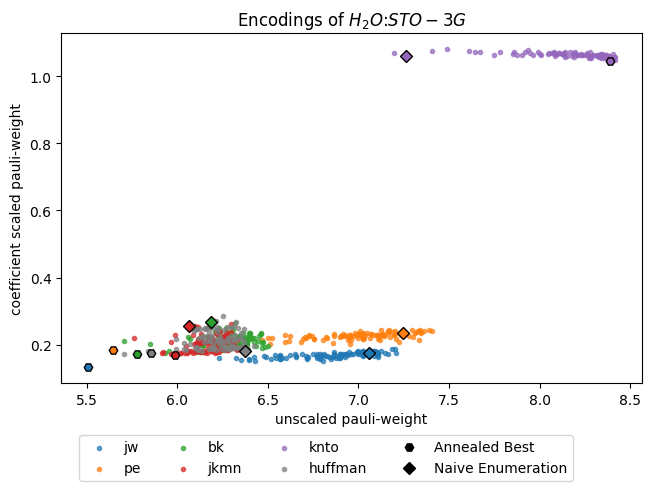

In [ ]:
ccolor_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "maxnto":"tab:purple", "huffman":"tab:grey"}
fig, ax = plt.subplots(layout="constrained")

for encoding, color in color_set.items():
    # ax.scatter([],[], label=encoding, marker=".", color=color, alpha=0.7)
    ax.scatter(sdmeans[encoding]["unscaled"], sdmeans[encoding]["scaled"], label=encoding, marker=".", color=color_set[encoding], alpha=0.7)
    ax.plot(sdmeans_naive[encoding]["unscaled"], sdmeans_naive[encoding]["scaled"], marker="D", color=color_set[encoding], mec="k")
    ax.plot(sdmeans_annealed[14][encoding]["unscaled"], sdmeans_annealed[14][encoding]["scaled"], marker="H", color=color, mec="k")


#Imports
import matplotlib.lines as mlines

# where some data has already been plotted to ax
handles, labels = plt.gca().get_legend_handles_labels()

# manually define a new patch 
naive_legend = mlines.Line2D([], [], color='black', label='Naive Enumeration', marker="D", linestyle="")
annealed_legend = mlines.Line2D([], [], color='black', label='Annealed Best', marker="H", linestyle="")

# handles is a list, so append manual patch
handles.extend([annealed_legend, naive_legend]) 

ax.set_xlabel("unscaled pauli-weight")
ax.set_ylabel("coefficient scaled pauli-weight")
ax.set_title("Encodings of $H_2 O$:$STO-3G$")
fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)

In [ ]:
from ferrmion.optimize import hamiltonian_adaptive_ternary_tree
from ferrmion.utils import fermionic_to_sparse_majorana

In [ ]:
mham = fermionic_to_sparse_majorana([(ones, "+-"),(twos,"++--")])

NameError: name 'ones' is not defined